# Feature Engineering and preprocessing
In this notebook, we will do the following:
- Combine 'diaBP' and 'sysBP' and create a Mean Arterial Presure (MAP) feature
- Address the imbalance of our heart disease risk column
- Rescale our features
- Remove redundant columns
- Trim outliers
- Create separate preprocessed datasets with different imputation techniques

In [30]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
# Read in raw data
df = pd.read_csv('../data/framingham.csv')

In [32]:
# Creating mean arterial pressure column
df['MAP'] = df.apply(
    lambda row: row['diaBP'] + (1/3) * (row['sysBP'] - row['diaBP']),
    axis = 1)

# Dropping 'sysBP' and 'diaBP'
df = df.drop(columns=['sysBP', 'diaBP'])
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,BMI,heartRate,glucose,TenYearCHD,MAP
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,26.97,80.0,77.0,0,82.000000
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,28.73,95.0,76.0,0,94.333333
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,25.34,75.0,70.0,0,95.833333
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,28.58,65.0,103.0,1,113.333333
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,23.10,85.0,85.0,0,99.333333


In [33]:
# Drop columns that were found to add negligible value
df.drop(columns=['education','prevalentStroke', 'currentSmoker', 'diabetes'])

,male,age,cigsPerDay,BPMeds,prevalentHyp,totChol,BMI,heartRate,glucose,TenYearCHD,MAP
0,1,39,0.0,0.0,0,195.0,26.97,80.0,77.0,0,82.000000
1,0,46,0.0,0.0,0,250.0,28.73,95.0,76.0,0,94.333333
2,1,48,20.0,0.0,0,245.0,25.34,75.0,70.0,0,95.833333
3,0,61,30.0,0.0,1,225.0,28.58,65.0,103.0,1,113.333333
4,0,46,23.0,0.0,0,285.0,23.10,85.0,85.0,0,99.333333
...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,20.0,NaN,0,248.0,22.00,84.0,86.0,0,91.666667
4236,0,44,15.0,0.0,0,210.0,19.16,86.0,NaN,0,100.166667
4237,0,52,0.0,0.0,0,269.0,21.47,80.0,107.0,0,99.833333
4238,1,40,0.0,0.0,1,185.0,25.60,67.0,72.0,0,112.333333


# Dealing with outliers
From the EDA phase, we identified the blood pressure columns as having some pretty significant outliers. Let us return to this but in the form of mean arterial pressure

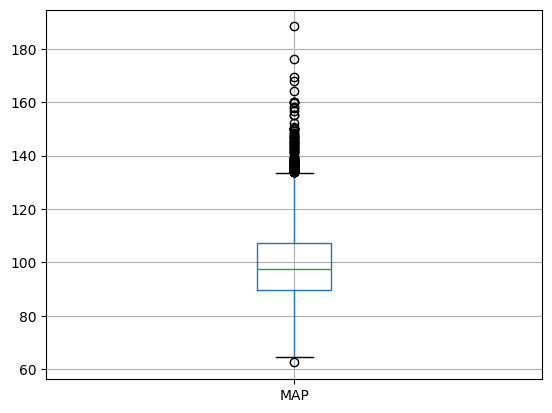

In [34]:
# Revisiting features with outliers
df.boxplot(column='MAP')
plt.show()

According to https://emcrit.org/wp-content/uploads/2016/11/HTNv3.pdf, a MAP of >140 mm usually constitutes a hypertensive crisis, though other sources report >160 mm as the threshold. https://pubmed.ncbi.nlm.nih.gov/16573454/

Our dataset has many points above the 140 mm level, so removing them would cause a loss of valuable information. However, values above 160 mm are most certainly acute emergency scenarios, and may not be particularly helpful in making long term predictions about heart disease risk. For this reason, we will cap these values at 160 mm

In [35]:
# Cap mean arterial pressure values at 160 (threshold for hypertensive crisis)
df['MAP'] = df['MAP'].clip(upper=160)

# Imputation
From our EDA, we also noted the absence of many values, particularly in the glucose column. We will address these missing values via simple imputation, as well as with k-Nearest Neighbors. Two separate csv files will be created with these approaches, and the model performance between the two will be evaluated in the modelling phase. 

Using a simple imputer

In [36]:
# Import the simple imputer
from sklearn.impute import SimpleImputer

# Make a copy of the dataframe
df_simple = pd.DataFrame(df)

# Make a list of the features to be imputed with the median
cont_features = ['age', 'cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose' ,'MAP']

# Create the imputer instance using the median to deal with continuous data
imputer_cont = SimpleImputer(strategy='median')

# Apply the imputation
df_simple[cont_features] = imputer_cont.fit_transform(df_simple[cont_features])

# Make a list of the features to be imputed with their most common values
cat_features = ['male', 'BPMeds', 'prevalentHyp']

# Create the imputer instance using the most frequent to deal with categorical data
imputer_cat = SimpleImputer(strategy='most_frequent')

# Apply the imputation
df_simple[cat_features] = imputer_cont.fit_transform(df_simple[cat_features])

# Save as a csv
df_simple.to_csv('../data/df_simple_imputed.csv', index=False)

Using k-Nearest Neighbors

In [37]:
# Import the KNN imputer
from sklearn.impute import KNNImputer

# Make a copy of the dataframe
df_knn = pd.DataFrame(df)

# Create the imputer instance
imputer_knn = KNNImputer(n_neighbors=5)

# Apply the imputation
df_knn_array = imputer_knn.fit_transform(df_knn)

# Convert the numpy array back to a pandas DF
df_knn = pd.DataFrame(df_knn_array, columns=df_knn.columns)

# Save as a csv
df_knn.to_csv('../data/df_knn_imputed.csv', index=False)

# Addressing the dependent variable imbalance
We noted that the ratio of those without a ten year risk of CHD to those with a risk is 5:1. To ensure that our models perform well, we will need to address this imbalance.

Here, SMOTENC will be used since we are dealing with a combination of numerical and categorical variables.

To maintain modularity, SMOTENC will be applied to both of the imputed datasets.

In [38]:
# Load in both datasets
df_simple = pd.read_csv('../data/df_simple_imputed.csv')
df_knn = pd.read_csv('../data/df_knn_imputed.csv')

In [39]:
# Applying SMOTENC to the simple imputed dataset

# Import libraries
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split

# Get independent variables
X = df_simple.drop(columns='TenYearCHD')

# Get dependent variable
y = df_simple['TenYearCHD']

# Make a list of the categorical features
cat_features = ['male', 'BPMeds', 'prevalentHyp', 'diabetes']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Drop NA values and ensure alignment
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

# Apply SMOTENC
smote_nc = SMOTENC(categorical_features=cat_features, random_state=42)
X_resampled, y_resampled = smote_nc.fit_resample(X_train, y_train)

# Make a new DataFrame with the resampled data
df_simp_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_simp_resampled['TenYearCHD'] = y_resampled

# Output as a csv file
df_simp_resampled.to_csv('../data/smotenc_simple_df.csv', index=False)

In [43]:
# Applying SMOTENC to the k-Nearest Neighbors imputed dataset

# Get independent variables
X = df_knn.drop(columns='TenYearCHD')

# Get dependent variable
y = df_knn['TenYearCHD']

# Make a list of the categorical features
cat_features = ['male', 'BPMeds', 'prevalentHyp', 'diabetes']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Drop NA values and ensure alignment
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

# Apply SMOTENC
smote_nc = SMOTENC(categorical_features=cat_features, random_state=42)
X_resampled, y_resampled = smote_nc.fit_resample(X_train, y_train)

# Make a new DataFrame with the resampled data
df_knn_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_knn_resampled['TenYearCHD'] = y_resampled

# Output as a csv file
df_simp_resampled.to_csv('../data/smotenc_knn_df.csv', index=False)

At this point, we have processed our original dataset to be much more suitable for model training, and will now proceed to the modelling phase.